# Brain Tumor Classification

Without dataset merge (training + testing) before preprocessing.

Hence,

`Acquire -> Split (Train & Test) -> Preprocess -> Split (Train & Val) -> Extract`


## Library Imports


In [181]:
import os
from glob import glob
from zipfile import ZipFile

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

## Dataset Acquisition


### Import

In [158]:
data_path = "./data/"
dataset_file = data_path + "brain-sartaj.zip"

zip = ZipFile(dataset_file)
zip.extractall(data_path)
zip.close()

print(os.listdir(data_path))

['brain-sartaj.zip', 'Testing', 'Training']


### Train Test Split

In [159]:
train_path = os.path.join(data_path, "Training")
test_path = os.path.join(data_path, "Testing")

classes = os.listdir(train_path)

print("Classes:", classes)

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


## Preprocessing

In [160]:
def preprocess(datapath, label, X, y, idx):
    images = glob(os.path.join(datapath, label, "*.jpg"))

    for img in images:
        img_raw = cv.imread(img)

        # Preprocess: Image Resizing
        img_resized = cv.resize(img_raw, (128, 128))

        # Preprocess: Image Grayscaling
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)

        # Preprocess: Image Normalizing
        img_normalized = img_grayscaled / 255

        X.append(img_normalized)
        y.append(idx)

In [161]:
X, y = [], []
X_test, y_test = [], []

for idx, label in enumerate(classes):
    preprocess(train_path, label, X, y, idx)
    preprocess(test_path, label, X_test, y_test, idx)

print("X data:", len(X))
print("y data:", len(y))
print("X_test data:", len(X_test))
print("y_test data:", len(y_test))

X data: 2870
y data: 2870
X_test data: 394
y_test data: 394


In [162]:
# plt.imshow(X[0], cmap="gray")

### Data Splitting


In [163]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42)

print("X_train data:", len(X_train))
print("y_train data:", len(y_train))
print("X_val data:", len(X_val))
print("y_val data:", len(y_val))

X_train data: 2296
y_train data: 2296
X_val data: 574
y_val data: 574


In [ ]:
# Store raw preprocessed image data
# without manual feature extraction process 
# for CNN classifier

X_train_cnn = X_train.copy()
y_train_cnn = y_train.copy()
X_val_cnn = X_val.copy()
y_val_cnn = y_val.copy()

print("X_train_cnn data:", len(X_train_cnn))
print("y_train_cnn data:", len(y_train_cnn))
print("X_val_cnn data:", len(X_val_cnn))
print("y_val_cnn data:", len(y_val_cnn))

X_train_cnn data: 2296
y_train_cnn data: 2296
X_val_cnn data: 574
y_val_cnn data: 574


## Feature Extraction

### Utility Functions

In [ ]:
# Convert binary to decimal pixel representation
def convert_bin_to_dec(bin):
    pows = [128, 64, 32, 16, 8, 4, 2, 1]
    dec = 0

    # Assign each binary digit to its decimal weight
    for bin_idx in range(len(bin)):
        dec += bin[bin_idx] * pows[bin_idx]

    return dec

### Local Binary Pattern (Classic)

In [166]:
def lbp(img):
    height, width = img.shape
    img_lbp = np.zeros((height, width), np.uint8)

    for i in range(height):
        for j in range(width):
            c = img[i, j]

            # Neighboring pixels' coordinates from the center
            p_coords = [(i-1, j-1), (i-1, j), (i-1, j+1), # top (pixel positions from the center)
                        (i, j+1),                         # right
                        (i+1, j+1), (i+1, j), (i+1, j-1), # bottom
                        (i, j-1)]                         # left
            
            # Each center pixel's binary representation from classic LBP
            c_lbp_bin = []

            for p_coord in p_coords:
                # Handle overflowed neighboring pixels outside the image
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for negative pixel indices (above & left of the image)
                    p = img[p_coord[0], p_coord[1]] if(p_coord[0] >= 0 and p_coord[1] >= 0) else 0
                except:
                    # Out of range pixel indices (below & right of the image)
                    p = 0

                # Threshold and append binary value to pixel representation
                p_lbp_bin_dig = 1 if(p > c) else 0
                c_lbp_bin.append(p_lbp_bin_dig)

            # Assign each pixels' decimal representation value to feature vector
            img_lbp[i][j] = convert_bin_to_dec(c_lbp_bin)

    return img_lbp

### nLBP


In [167]:
def nlbp(img, distance):
    height, width = img.shape
    img_nlbp = np.zeros((height, width), np.uint8)
    
    for i in range(height):
        for j in range(width):
            # Neighboring pixels' coordinates from the center
            p_coords = [(i-1, j-1), (i-1, j), (i-1, j+1), # top (pixel positions from the center)
                        (  i, j+1),                       # right
                        (i+1, j+1), (i+1, j), (i+1, j-1), # bottom
                        (  i, j-1)]                       # left
            
            # Each center pixel's binary representation from nLBP
            c_nlbp_bin = []

            for p_coord_idx in range(len(p_coords)):
                # Coordinates of the two neighboring pixels based on the chosen d parameter
                p_a_idx = p_coord_idx
                p_b_idx = (p_coord_idx + distance) % 8

                # Handle overflowed neighboring pixels outside the image
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for outer edge of the first neighboring pixel (above & left)
                    p_a_bin_dig = 0 if(-1 in p_coords[p_a_idx]) else img[p_coords[p_a_idx]]
                except:
                    # Out of range pixel indices (below & right)
                    p_a_bin_dig = 0
                
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for outer edge of the second neighboring pixel (above & left)
                    p_b_bin_dig = 0 if(-1 in p_coords[p_b_idx]) else img[p_coords[p_b_idx]]
                except:
                    # Out of range pixel indices (below & right)
                    p_b_bin_dig = 0

                # Threshold and append binary value to pixel representation
                p_nlbp_bin_val = 1 if(p_a_bin_dig > p_b_bin_dig) else 0
                c_nlbp_bin.append(p_nlbp_bin_val)

            # Assign each pixels' decimal representation value to feature vector
            img_nlbp[i][j] = convert_bin_to_dec(c_nlbp_bin)

    return img_nlbp

### αLBP


In [ ]:
def albp(img, alpha):
    height, width = img.shape
    img_albp = np.zeros((height, width), np.uint8)

    # Neighboring pixel's coordinate candidates 
    # based on the chosen alpha parameter
    p_crds_list = {
        0  : [( 0, 4), ( 0, 3), ( 0, 2), ( 0, 1), ( 0,-1), ( 0,-2), ( 0,-3), ( 0,-4)],
        45 : [(-4, 4), (-3, 3), (-2, 2), (-1, 1), ( 1,-1), ( 2,-2), ( 3,-3), ( 4,-4)],
        90 : [( 4, 0), ( 3, 0), ( 2, 0), ( 1, 0), (-1, 0), (-2, 0), (-3, 0), (-4, 0)],
        135: [(-4,-4), (-3,-3), (-2,-2), (-1,-1), ( 1, 1), ( 2, 2), ( 3, 3), ( 4, 4)],
    }

    for i in range(height):
        for j in range(width):
            c = img[i][j] 
            
            # Handle alpha parameter input outside scope
            if(alpha % 360 not in p_crds_list):
                return print("Incorrect alpha parameter value")
            
            # Chosen neighboring pixels based on the alpha parameter
            p_crds = p_crds_list[alpha]

            # Each pixel's binary representation from αLBP
            c_albp_bin = []

            for p in p_crds:
                # Handle overflowed neighboring pixels outside the image
                try:
                    # Coordinates of the neighboring pixels based on their center
                    i_crd = i + p[0]
                    j_crd = j + p[1]

                    # Find neighboring pixel of a center pixel
                    # Assign 0 for negative pixel indices (above & left of the image)
                    p = img[i_crd, j_crd] if (i_crd >= 0 and j_crd >= 0) else 0 
                except:
                    # Out of range pixel indices (below & right)
                    p = 0

                # Threshold and append binary value to pixel representation
                p_albp_bin_dig = 1 if p > c else 0
                c_albp_bin.append(p_albp_bin_dig)

            # Assign each pixels' decimal representation value to feature vector
            img_albp[i, j] = convert_bin_to_dec(c_albp_bin)
    
    return img_albp

### TODO: MB-LBP

### Tests

In [ ]:
# TESTS

# dum = [[0, 1, 2],
#        [3, 4, 5],
#        [6, 7, 8]]

# dum = [[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
#        [10,11,12,13,14,15,16,17,18,19],
#        [20,21,22,23,24,25,26,27,28,29],
#        [30,31,32,33,34,35,36,37,38,39],
#        [40,41,42,43,44,45,46,47,48,49],
#        [50,51,52,53,54,55,56,57,58,59],
#        [60,61,62,63,64,65,66,67,68,69],
#        [70,71,72,73,74,75,76,77,78,79],
#        [80,81,82,83,84,85,86,87,88,89],
#        [90,91,92,93,94,95,96,97,98,99]]

# dum_lbp = lbp(np.array(dum)).flatten()
# dum_nlbp = nlbp(np.array(dum), 2).flatten()
# dum_albp = albp(np.array(dum), 135).flatten()

# print("LBP", "\n", dum_lbp)
# print("nLBP", "\n", dum_nlbp)
# print("aLBP", "\n", dum_albp)

LBP 
 [28 30 30 30 30 30 30 30 30  6 28 30 30 30 30 30 30 30 30  6 28 30 30 30
 30 30 30 30 30  6 28 30 30 30 30 30 30 30 30  6 28 30 30 30 30 30 30 30
 30  6 28 30 30 30 30 30 30 30 30  6 28 30 30 30 30 30 30 30 30  6 28 30
 30 30 30 30 30 30 30  6 28 30 30 30 30 30 30 30 30  6 16 16 16 16 16 16
 16 16 16  0]
nLBP 
 [ 12  14  15  15  15  15  15  15  15   7  12  15  15  15  15  15  15  15
  15 199  12  15  15  15  15  15  15  15  15 199  12  15  15  15  15  15
  15  15  15 199  12  15  15  15  15  15  15  15  15 199  12  15  15  15
  15  15  15  15  15 199  12  15  15  15  15  15  15  15  15 199  12  15
  15  15  15  15  15  15  15 199  12  15  15  15  15  15  15  15  15 199
  48  49  49  49  49  49  49  49  49 193]
aLBP 
 [15 15 15 15 15 15 14 12  8  0 15 15 15 15 15 15 14 12  8  0 15 15 15 15
 15 15 14 12  8  0 15 15 15 15 15 15 14 12  8  0 15 15 15 15 15 15 14 12
  8  0 15 15 15 15 15 15 14 12  8  0 14 14 14 14 14 14 14 12  8  0 12 12
 12 12 12 12 12 12  8  0  8  8  8  8  8  8  8  8

### TODO: HISTOGRAM REPRESENTATION

### Execute Extraction

In [192]:
# Define feature extracted data for training input
X_train_lbp, X_val_lbp = [], []
X_train_nlbp, X_val_nlbp = [], []
X_train_albp, X_val_albp = [], []

# Extract X_train images
for i, x in enumerate(X_train):
    X_train_lbp.append(lbp(x).flatten())
    X_train_nlbp.append(nlbp(x,1).flatten())
    X_train_albp.append(albp(x,0).flatten())
    print(f"{i}/{len(X_train)} X_train images extracted")

# Extract X_val images
for i, x in enumerate(X_val):
    X_val_lbp.append(lbp(x).flatten())
    X_val_nlbp.append(nlbp(x,1).flatten())
    X_val_albp.append(albp(x,0).flatten())
    print(f"{i}/{len(X_val)} X_val images extracted")

print("Image samples before feature extraction")
print(X_train[0])
print(X_train_lbp[0])
print(X_train_nlbp[0])
print(X_train_albp[0])

print("Extracted image feature samples")
print(X_val[0])
print(X_val_lbp[0])
print(X_val_nlbp[0])
print(X_val_albp[0])

0/2296 X_train images extracted
1/2296 X_train images extracted
2/2296 X_train images extracted
3/2296 X_train images extracted
4/2296 X_train images extracted
5/2296 X_train images extracted
6/2296 X_train images extracted
7/2296 X_train images extracted
8/2296 X_train images extracted
9/2296 X_train images extracted
10/2296 X_train images extracted
11/2296 X_train images extracted
12/2296 X_train images extracted
13/2296 X_train images extracted
14/2296 X_train images extracted
15/2296 X_train images extracted
16/2296 X_train images extracted
17/2296 X_train images extracted
18/2296 X_train images extracted
19/2296 X_train images extracted
20/2296 X_train images extracted
21/2296 X_train images extracted
22/2296 X_train images extracted
23/2296 X_train images extracted
24/2296 X_train images extracted
25/2296 X_train images extracted
26/2296 X_train images extracted
27/2296 X_train images extracted
28/2296 X_train images extracted
29/2296 X_train images extracted
30/2296 X_train imag

## Classification

### Evaluation Functions

In [193]:
def evaluate_model(model_name, y_val, model_preds, model_time):

    # Confusion matrix of trained model
    cm = confusion_matrix(y_val, model_preds)
    cm_disp = ConfusionMatrixDisplay(cm, display_labels=[c.removesuffix("_tumor") for c in classes])
    cm_disp.plot(cmap='cividis')
    plt.show()

    # Global performance measures
    tp, tn, fp, fn = 0, 0, 0, 0
    acc, prec, rec, f1 = 0, 0, 0, 0 
    local_perf = []

    # Evaluation matrices of trained model
    # Model predictions and performance for each classes and global-scoped
    for c in range(len(classes)):
        # Model predidctions for each class
        tp_c = cm[c,c]
        tp += tp_c
        
        tn_c = cm.sum() - cm[c,:].sum() - cm[:,c].sum() + cm[c,c]
        tn += tn_c

        fp_c = cm[:,c].sum() - cm[c,c]
        fp += fp_c

        fn_c = cm[c,:].sum() - cm[c,c]
        fn += fn_c

        # Model performance
        acc_c = (tp_c + tn_c) / (tp_c + tn_c + fp_c + fn_c)
        acc += acc_c / 4

        prec_c = tp_c / (tp_c + fp_c)
        prec += prec_c / 4

        rec_c = tp_c / (tp_c + fn_c)
        rec += rec_c / 4

        f1_c = 2 * ((prec_c * rec_c) / (prec_c + rec_c))
        f1 += f1_c / 4

        # Assign model performance of each class
        local_perf.append({
            "accuracy": acc_c,
            "precision": prec_c,
            "recall": rec_c,
            "f1-score": f1_c
        })

    acc_macro = (tp / cm.sum())

    # Assign model performance in global-scoped
    global_perf = { 
        "accuracy": acc, 
        "accuracy_macro": acc_macro, 
        "precision": prec,
        "recall": rec,
        "f1-score": f1
    }

    # Display model performance evaluation results
    display_evaluation(model_name, local_perf, global_perf, model_time)

    return local_perf, global_perf

def display_evaluation(model_name, local_perf, global_perf, model_time):
    print(f"Model & Params: {model_name}")
    print(f"Training Time : {model_time} seconds")

    for i, lp in enumerate(local_perf):
        print(f"\nLocal Performance for Class \"{classes[i]}\"")
        print(f"Accuracy : {lp["accuracy"]}",
              f"Precision: {lp["precision"]}",
              f"Recall   : {lp["recall"]}",
              f"F1-Score : {lp["f1-score"]}",
              sep="\n")
        
    print(f"\nGlobal Performance")
    print(f"Accuracy : {global_perf["accuracy"]} | {global_perf["accuracy_macro"]}",
          f"Precision: {global_perf["precision"]}",
          f"Recall   : {global_perf["recall"]}",
          f"F1-Score : {global_perf["f1-score"]}",
          sep="\n")


### Classic Machine Learning

#### K-Nearest Neighbor Model

- 3 Neighbors

In [194]:
# Define KNN model with 3 neighbors
knn_classifier_3 = KNeighborsClassifier(n_neighbors=3)

# Train LBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_3_lbp_time = end - start
# Test LBP
knn_3_lbp_preds = knn_classifier_3.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_3_nlbp_time = end - start
# Test nLBP
knn_3_nlbp_preds = knn_classifier_3.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_3_albp_time = end - start
# Test aLBP
knn_3_albp_preds = knn_classifier_3.predict(X_val_albp)

- 5 Neighbors

In [195]:
# Define KNN model with 5 neighbors
knn_classifier_5 = KNeighborsClassifier(n_neighbors=5)

# Train LBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_5_lbp_time = end - start
# Test LBP
knn_5_lbp_preds = knn_classifier_5.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_5_nlbp_time = end - start
# Test nLBP
knn_5_nlbp_preds = knn_classifier_5.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_5_albp_time = end - start
# Test aLBP
knn_5_albp_preds = knn_classifier_5.predict(X_val_albp)

- 7 Neighbors

In [196]:
# Define KNN model with 7 neighbors
knn_classifier_7 = KNeighborsClassifier(n_neighbors=7)

# Train LBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_7_lbp_time = end - start
# Test LBP
knn_7_lbp_preds = knn_classifier_7.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_7_nlbp_time = end - start
# Test nLBP
knn_7_nlbp_preds = knn_classifier_7.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_7_albp_time = end - start
# Test aLBP
knn_7_albp_preds = knn_classifier_7.predict(X_val_albp)

#### KNN Evaluation

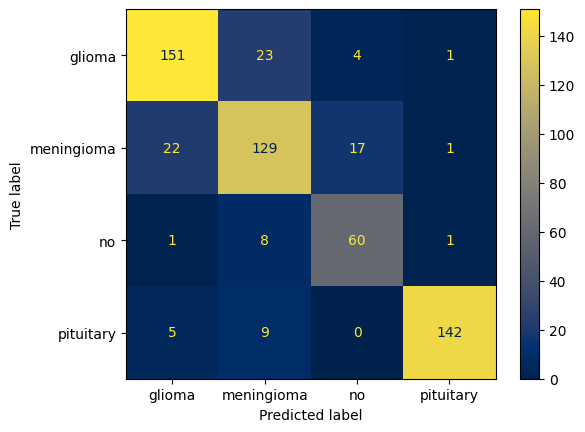

Model & Params: KNN - 3 Neighbors - LBP
Training Time : 0.007206433001556434 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.9024390243902439
Precision: 0.8435754189944135
Recall   : 0.8435754189944135
F1-Score : 0.8435754189944135

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8606271777003485
Precision: 0.7633136094674556
Recall   : 0.7633136094674556
F1-Score : 0.7633136094674556

Local Performance for Class "no_tumor"
Accuracy : 0.945993031358885
Precision: 0.7407407407407407
Recall   : 0.8571428571428571
F1-Score : 0.794701986754967

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9703832752613241
Precision: 0.9793103448275862
Recall   : 0.9102564102564102
F1-Score : 0.9435215946843852

Global Performance
Accuracy : 0.9198606271777003 | 0.8397212543554007
Precision: 0.8317350285075489
Recall   : 0.8435720739652841
F1-Score : 0.8362781524753053


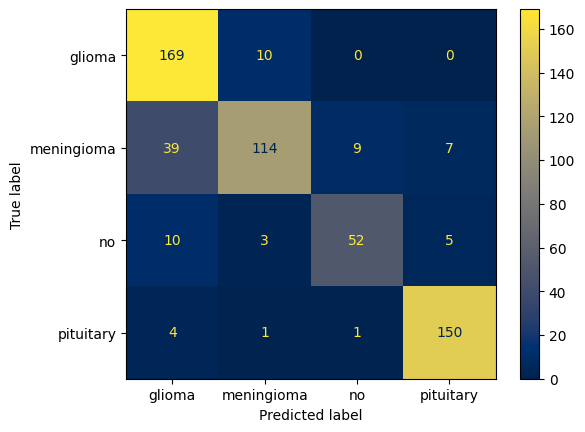

Model & Params: KNN - 3 Neighbors - nLBP
Training Time : 0.006982981001783628 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.8902439024390244
Precision: 0.7612612612612613
Recall   : 0.9441340782122905
F1-Score : 0.8428927680798004

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8797909407665505
Precision: 0.890625
Recall   : 0.6745562130177515
F1-Score : 0.7676767676767677

Local Performance for Class "no_tumor"
Accuracy : 0.9512195121951219
Precision: 0.8387096774193549
Recall   : 0.7428571428571429
F1-Score : 0.787878787878788

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9686411149825784
Precision: 0.9259259259259259
Recall   : 0.9615384615384616
F1-Score : 0.9433962264150944

Global Performance
Accuracy : 0.9224738675958188 | 0.8449477351916377
Precision: 0.8541304661516356
Recall   : 0.8307714739064116
F1-Score : 0.8354611375126126


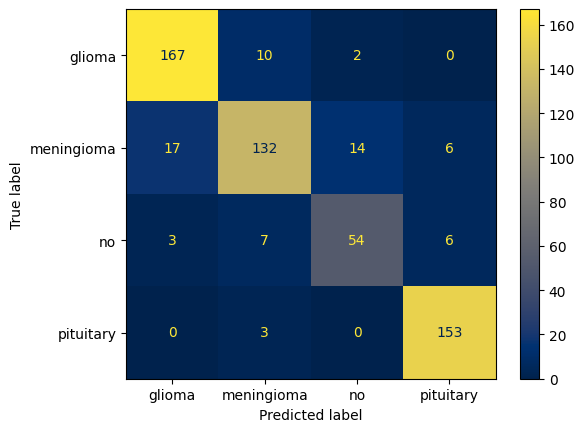

Model & Params: KNN - 3 Neighbors - aLBP
Training Time : 0.0076883240035385825 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.9442508710801394
Precision: 0.893048128342246
Recall   : 0.9329608938547486
F1-Score : 0.912568306010929

Local Performance for Class "meningioma_tumor"
Accuracy : 0.9006968641114983
Precision: 0.868421052631579
Recall   : 0.7810650887573964
F1-Score : 0.822429906542056

Local Performance for Class "no_tumor"
Accuracy : 0.9442508710801394
Precision: 0.7714285714285715
Recall   : 0.7714285714285715
F1-Score : 0.7714285714285715

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9738675958188153
Precision: 0.9272727272727272
Recall   : 0.9807692307692307
F1-Score : 0.9532710280373831

Global Performance
Accuracy : 0.9407665505226481 | 0.8815331010452961
Precision: 0.865042619918781
Recall   : 0.8665559462024868
F1-Score : 0.8649244530047349


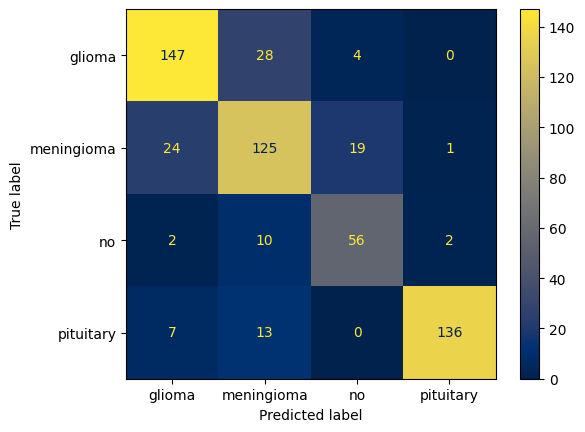

Model & Params: KNN - 5 Neighbors - LBP
Training Time : 0.01093301299988525 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.8867595818815331
Precision: 0.8166666666666667
Recall   : 0.8212290502793296
F1-Score : 0.8189415041782729

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8344947735191638
Precision: 0.7102272727272727
Recall   : 0.7396449704142012
F1-Score : 0.7246376811594203

Local Performance for Class "no_tumor"
Accuracy : 0.9355400696864111
Precision: 0.7088607594936709
Recall   : 0.8
F1-Score : 0.7516778523489933

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9599303135888502
Precision: 0.9784172661870504
Recall   : 0.8717948717948718
F1-Score : 0.9220338983050846

Global Performance
Accuracy : 0.9041811846689896 | 0.8083623693379791
Precision: 0.8035429912686651
Recall   : 0.8081672231221007
F1-Score : 0.8043227339979429


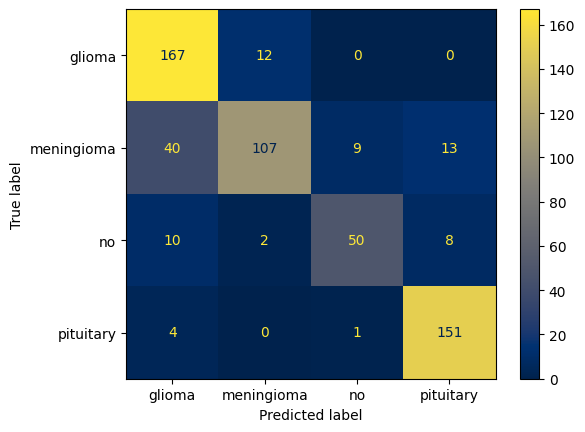

Model & Params: KNN - 5 Neighbors - nLBP
Training Time : 0.007631052998476662 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.8850174216027874
Precision: 0.755656108597285
Recall   : 0.9329608938547486
F1-Score : 0.8350000000000001

Local Performance for Class "meningioma_tumor"
Accuracy : 0.867595818815331
Precision: 0.8842975206611571
Recall   : 0.6331360946745562
F1-Score : 0.7379310344827587

Local Performance for Class "no_tumor"
Accuracy : 0.9477351916376306
Precision: 0.8333333333333334
Recall   : 0.7142857142857143
F1-Score : 0.7692307692307692

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9547038327526133
Precision: 0.877906976744186
Recall   : 0.967948717948718
F1-Score : 0.9207317073170732

Global Performance
Accuracy : 0.9137630662020907 | 0.8275261324041812
Precision: 0.8377984848339903
Recall   : 0.8120828551909343
F1-Score : 0.8157233777576502


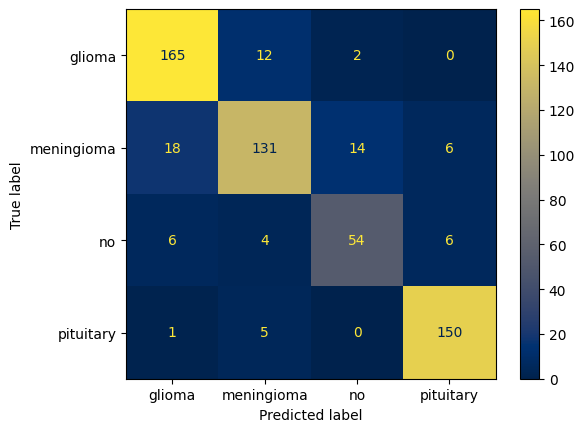

Model & Params: KNN - 5 Neighbors - aLBP
Training Time : 0.008534729000530206 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.9320557491289199
Precision: 0.868421052631579
Recall   : 0.9217877094972067
F1-Score : 0.894308943089431

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8972125435540069
Precision: 0.8618421052631579
Recall   : 0.7751479289940828
F1-Score : 0.8161993769470405

Local Performance for Class "no_tumor"
Accuracy : 0.9442508710801394
Precision: 0.7714285714285715
Recall   : 0.7714285714285715
F1-Score : 0.7714285714285715

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9686411149825784
Precision: 0.9259259259259259
Recall   : 0.9615384615384616
F1-Score : 0.9433962264150944

Global Performance
Accuracy : 0.9355400696864111 | 0.8710801393728222
Precision: 0.8569044138123085
Recall   : 0.8574756678645806
F1-Score : 0.8563332794700342


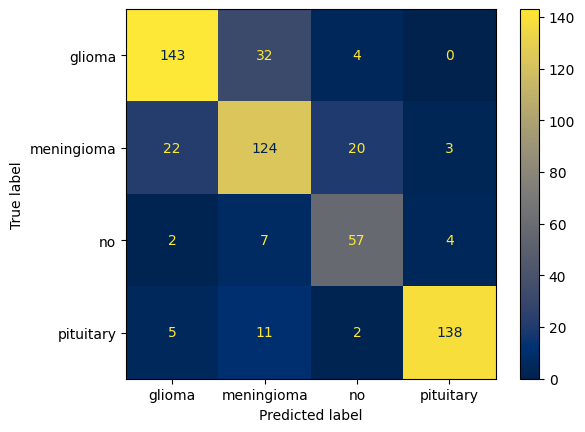

Model & Params: KNN - 7 Neighbors - LBP
Training Time : 0.009506975999101996 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.8867595818815331
Precision: 0.8313953488372093
Recall   : 0.7988826815642458
F1-Score : 0.8148148148148147

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8344947735191638
Precision: 0.7126436781609196
Recall   : 0.7337278106508875
F1-Score : 0.7230320699708455

Local Performance for Class "no_tumor"
Accuracy : 0.9320557491289199
Precision: 0.6867469879518072
Recall   : 0.8142857142857143
F1-Score : 0.7450980392156863

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9564459930313589
Precision: 0.9517241379310345
Recall   : 0.8846153846153846
F1-Score : 0.9169435215946844

Global Performance
Accuracy : 0.9024390243902439 | 0.8048780487804879
Precision: 0.7956275382202427
Recall   : 0.807877897779058
F1-Score : 0.7999721113990077


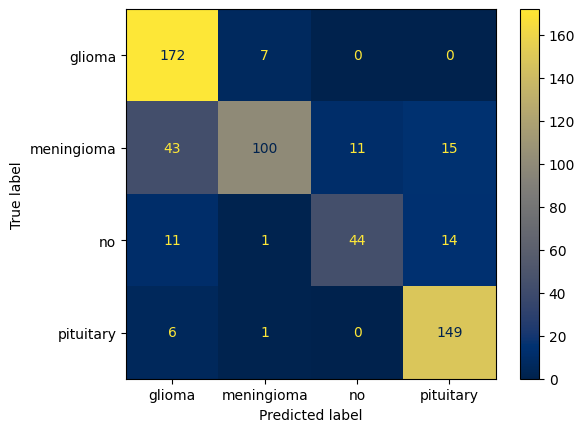

Model & Params: KNN - 7 Neighbors - nLBP
Training Time : 0.008969618000264745 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.8832752613240418
Precision: 0.7413793103448276
Recall   : 0.9608938547486033
F1-Score : 0.8369829683698298

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8641114982578397
Precision: 0.9174311926605505
Recall   : 0.591715976331361
F1-Score : 0.7194244604316546

Local Performance for Class "no_tumor"
Accuracy : 0.9355400696864111
Precision: 0.8
Recall   : 0.6285714285714286
F1-Score : 0.7040000000000001

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9372822299651568
Precision: 0.8370786516853933
Recall   : 0.9551282051282052
F1-Score : 0.8922155688622755

Global Performance
Accuracy : 0.9050522648083623 | 0.8101045296167247
Precision: 0.8239722886726929
Recall   : 0.7840773661948995
F1-Score : 0.7881557494159399


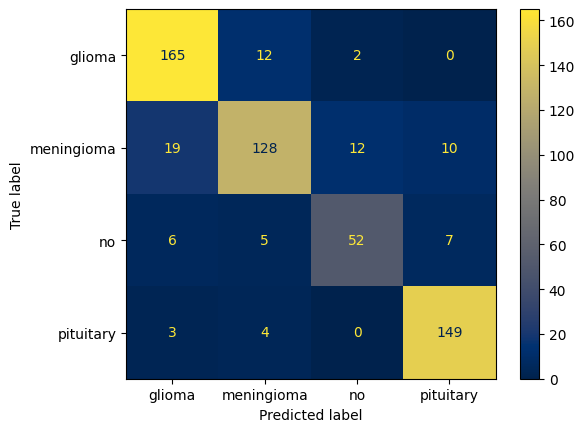

Model & Params: KNN - 7 Neighbors - aLBP
Training Time : 0.008406209999520797 seconds

Local Performance for Class "glioma_tumor"
Accuracy : 0.926829268292683
Precision: 0.8549222797927462
Recall   : 0.9217877094972067
F1-Score : 0.8870967741935484

Local Performance for Class "meningioma_tumor"
Accuracy : 0.89198606271777
Precision: 0.8590604026845637
Recall   : 0.757396449704142
F1-Score : 0.8050314465408804

Local Performance for Class "no_tumor"
Accuracy : 0.9442508710801394
Precision: 0.7878787878787878
Recall   : 0.7428571428571429
F1-Score : 0.7647058823529412

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9581881533101045
Precision: 0.8975903614457831
Recall   : 0.9551282051282052
F1-Score : 0.9254658385093167

Global Performance
Accuracy : 0.9303135888501742 | 0.8606271777003485
Precision: 0.8498629579504703
Recall   : 0.8442923767966742
F1-Score : 0.8455749853991716


In [197]:
# Evaluate KNN model classifier
knn_3_lbp_eval = evaluate_model("KNN - 3 Neighbors - LBP", y_val, knn_3_lbp_preds, knn_3_lbp_time)
knn_3_nlbp_eval = evaluate_model("KNN - 3 Neighbors - nLBP", y_val, knn_3_nlbp_preds, knn_3_nlbp_time)
knn_3_albp_eval = evaluate_model("KNN - 3 Neighbors - aLBP", y_val, knn_3_albp_preds, knn_3_albp_time)

knn_5_lbp_eval = evaluate_model("KNN - 5 Neighbors - LBP", y_val, knn_5_lbp_preds, knn_5_lbp_time)
knn_5_nlbp_eval = evaluate_model("KNN - 5 Neighbors - nLBP", y_val, knn_5_nlbp_preds, knn_5_nlbp_time)
knn_5_albp_eval = evaluate_model("KNN - 5 Neighbors - aLBP", y_val, knn_5_albp_preds, knn_5_albp_time)

knn_7_lbp_eval = evaluate_model("KNN - 7 Neighbors - LBP", y_val, knn_7_lbp_preds, knn_7_lbp_time)
knn_7_nlbp_eval = evaluate_model("KNN - 7 Neighbors - nLBP", y_val, knn_7_nlbp_preds, knn_7_nlbp_time)
knn_7_albp_eval = evaluate_model("KNN - 7 Neighbors - aLBP", y_val, knn_7_albp_preds, knn_7_albp_time)


#### Decision Tree

In [ ]:
# Define Decision Tree model classifier
dt_classifier = DecisionTreeClassifier()

# Train Decision Tree model classifier
dt_classifier.fit(X_train, y_train)

# Test Decision Tree model classifier
dt_preds = dt_classifier.predict(X_val)

In [ ]:
# Evaluate Decision Tree model classifier
dt_eval = evaluate_model("Decision Tree", y_val, dt_preds)

### Random Forest

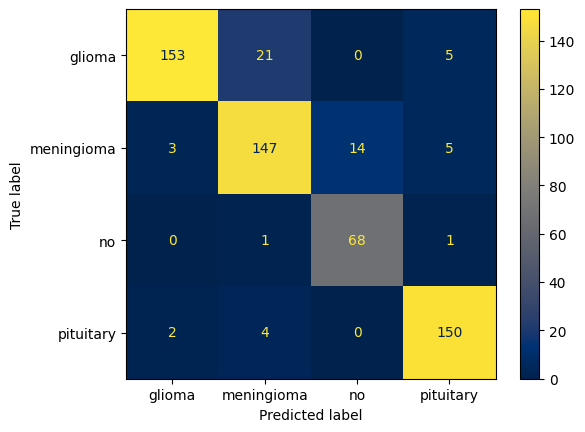

Random Forest Local Performance for Class "glioma_tumor"
Accuracy : 0.945993031358885
Precision: 0.9683544303797469
Recall   : 0.8547486033519553
F1-Score : 0.9080118694362018
Random Forest Local Performance for Class "meningioma_tumor"
Accuracy : 0.9163763066202091
Precision: 0.8497109826589595
Recall   : 0.8698224852071006
F1-Score : 0.8596491228070176
Random Forest Local Performance for Class "no_tumor"
Accuracy : 0.9721254355400697
Precision: 0.8292682926829268
Recall   : 0.9714285714285714
F1-Score : 0.8947368421052632
Random Forest Local Performance for Class "pituitary_tumor"
Accuracy : 0.9703832752613241
Precision: 0.9316770186335404
Recall   : 0.9615384615384616
F1-Score : 0.9463722397476341

Random Forest Global Performance
Accuracy : 0.9512195121951219 | 0.9024390243902439
Precision: 0.8947526810887934
Recall   : 0.9143845303815222
F1-Score : 0.9021925185240292


In [ ]:
# Define Random Forest model classifier
rf_classifier = RandomForestClassifier()

# Train Random Forest model classifier
rf_classifier.fit(X_train, y_train)

# Test Random Forest model classifier
rf_preds = rf_classifier.predict(X_val)

# Evaluate Random Forest model classifier
rf_eval = evaluate_model("Random Forest", y_val, rf_preds)

### Naive Bayes

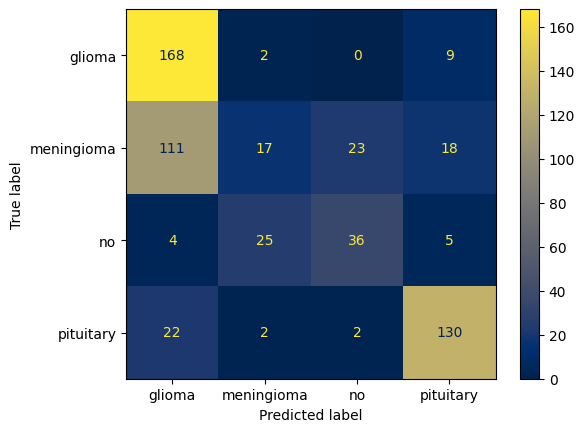

Gaussian Naive Bayes Local Performance for Class "glioma_tumor"
Accuracy : 0.7421602787456446
Precision: 0.5508196721311476
Recall   : 0.9385474860335196
F1-Score : 0.6942148760330579
Gaussian Naive Bayes Local Performance for Class "meningioma_tumor"
Accuracy : 0.6846689895470384
Precision: 0.3695652173913043
Recall   : 0.10059171597633136
F1-Score : 0.15813953488372093
Gaussian Naive Bayes Local Performance for Class "no_tumor"
Accuracy : 0.8972125435540069
Precision: 0.5901639344262295
Recall   : 0.5142857142857142
F1-Score : 0.5496183206106869
Gaussian Naive Bayes Local Performance for Class "pituitary_tumor"
Accuracy : 0.8989547038327527
Precision: 0.8024691358024691
Recall   : 0.8333333333333334
F1-Score : 0.8176100628930817

Gaussian Naive Bayes Global Performance
Accuracy : 0.8057491289198606 | 0.6114982578397212
Precision: 0.5782544899377876
Recall   : 0.5966895624072246
F1-Score : 0.5548956986051369


In [ ]:
# Define Naive Bayes model classifier
gnb_classifier = GaussianNB()

# Train Naive Bayes model classifier
gnb_classifier.fit(X_train, y_train)

# Test Naive Bayes model classifier
gnb_preds = gnb_classifier.predict(X_val)

# Evaluate Naive Bayes model classifier
gnb_eval = evaluate_model("Gaussian Naive Bayes", y_val, gnb_preds)

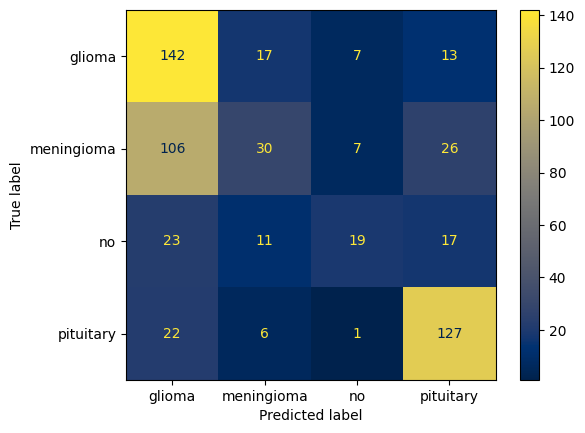

Multinomial Naive Bayes Local Performance for Class "glioma_tumor"
Accuracy : 0.6724738675958188
Precision: 0.48464163822525597
Recall   : 0.7932960893854749
F1-Score : 0.6016949152542372
Multinomial Naive Bayes Local Performance for Class "meningioma_tumor"
Accuracy : 0.6986062717770035
Precision: 0.46875
Recall   : 0.17751479289940827
F1-Score : 0.2575107296137339
Multinomial Naive Bayes Local Performance for Class "no_tumor"
Accuracy : 0.8850174216027874
Precision: 0.5588235294117647
Recall   : 0.2714285714285714
F1-Score : 0.36538461538461536
Multinomial Naive Bayes Local Performance for Class "pituitary_tumor"
Accuracy : 0.8519163763066202
Precision: 0.6939890710382514
Recall   : 0.8141025641025641
F1-Score : 0.7492625368731564

Multinomial Naive Bayes Global Performance
Accuracy : 0.7770034843205574 | 0.554006968641115
Precision: 0.551551059668818
Recall   : 0.5140855044540047
F1-Score : 0.49346319928143567


In [ ]:
# Define Naive Bayes model classifier
mnb_classifier = MultinomialNB()

# Train Naive Bayes model classifier
mnb_classifier.fit(X_train, y_train)

# Test Naive Bayes model classifier
mnb_preds = mnb_classifier.predict(X_val)

# Evaluate Naive Bayes model classifier
mnb_eval = evaluate_model("Multinomial Naive Bayes", y_val, mnb_preds)

#### Support Vector Machine

In [ ]:
# classifier = SVC()
# classifier.fit(X_train, y_train)

# classifier.predict(X_test)